# Informe Teórico Práctico 2: Regresión Lineal (Titanic)

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** pasajeros del Titanic (`Titanic-Dataset.csv`)


Punto 1.1 del taller con el dataset del Titanic. Como la variable típica del Titanic (sobrevivió o no) es binaria, para regresión lineal necesitamos otra variable numérica continua. Escogimos la **tarifa** que pagó cada pasajero.

**Concepto: regresión lineal.** Ajusta una recta (o un hiperplano con varias variables) $\hat{y} = b_0 + b_1 x_1 + \dots + b_n x_n$ escogiendo los coeficientes que minimizan la suma de errores al cuadrado. Sirve para predecir valores numéricos, y cada coeficiente dice cuánto cambia la predicción cuando su variable sube en una unidad.

## 1. Carga del dataset

El archivo tiene 891 pasajeros y 12 columnas: identificador, si sobrevivió, clase del tiquete, nombre, sexo, edad, hermanos o pareja a bordo (`SibSp`), padres o hijos a bordo (`Parch`), número de tiquete, tarifa, cabina y puerto de embarque.

In [1]:
# Librerias que usamos en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../Titanic-Dataset.csv")
print("Filas y columnas:", df_raw.shape)
print("Filas duplicadas:", df_raw.duplicated().sum())
df_raw.head()

Filas y columnas: (891, 12)
Filas duplicadas: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Tipo de dato y faltantes por columna
pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
})

,tipo,faltantes,% faltantes
PassengerId,int64,0,0.0
Survived,int64,0,0.0
Pclass,int64,0,0.0
Name,str,0,0.0
Sex,str,0,0.0
Age,float64,177,19.9
SibSp,int64,0,0.0
Parch,int64,0,0.0
Ticket,str,0,0.0
Fare,float64,0,0.0


## 2. Limpieza y transformación

Hay tres columnas con faltantes:

1. **Cabin** (77 % faltante). Imputar tanto no tiene sentido. Lo que sí se puede usar es el hecho de tener o no cabina registrada, que está muy ligado a la clase del pasajero. Creamos `tiene_cabina`.
2. **Age** (cerca del 20 % faltante). Rellenarla con la mediana general mezclaría niños con adultos. El nombre trae un título (`Mr`, `Mrs`, `Miss`, `Master`) que dice mucho de la edad: `Master` se usaba para niños y `Miss` para mujeres solteras, muchas de ellas jóvenes. Llenamos la edad con la mediana de cada título y guardamos una bandera `edad_faltante`.
3. **Embarked** (2 filas). Se llenan con el puerto más frecuente (Southampton).

Además creamos `tamano_familia` (`SibSp + Parch + 1`) y `viaja_solo`, pasamos `Sex` a 0/1 y el puerto y el título a one hot. `PassengerId`, `Name`, `Ticket` y `Cabin` no se usan directamente como entrada: el identificador no significa nada y los otros tres son texto casi único por persona.

In [4]:
def limpiar_titanic(df_raw):
    df = df_raw.copy()

    # Titulo que aparece en el nombre, entre la coma y el punto: "Braund, Mr. Owen Harris" da "Mr"
    df["titulo"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
    df["titulo"] = df["titulo"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    comunes = ["Mr", "Mrs", "Miss", "Master"]
    df.loc[~df["titulo"].isin(comunes), "titulo"] = "Otro"

    # Edad faltante: mediana del mismo titulo y una bandera
    df["edad_faltante"] = df["Age"].isna().astype(int)
    df["Age"] = df["Age"].fillna(df.groupby("titulo")["Age"].transform("median"))

    # Puerto faltante: el mas frecuente
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # Variables nuevas
    df["tiene_cabina"] = df["Cabin"].notna().astype(int)
    df["sexo"] = (df["Sex"] == "female").astype(int)  # 1 mujer, 0 hombre
    df["tamano_familia"] = df["SibSp"] + df["Parch"] + 1
    df["viaja_solo"] = (df["tamano_familia"] == 1).astype(int)
    df["log_tarifa"] = np.log1p(df["Fare"])

    # One hot de puerto y titulo
    dummies = pd.get_dummies(df[["Embarked", "titulo"]], prefix=["puerto", "titulo"], dtype=int)
    df = pd.concat([df, dummies], axis=1)
    return df


df = limpiar_titanic(df_raw)
cols_puerto = [c for c in df.columns if c.startswith("puerto_")]
cols_titulo = [c for c in df.columns if c.startswith("titulo_")]
print("Faltantes que quedan en las columnas usadas:", df[["Age", "Embarked", "Fare"]].isna().sum().sum())
df[["Survived", "Pclass", "sexo", "Age", "titulo", "tamano_familia", "Fare", "tiene_cabina", "Embarked"]].head(8)

Faltantes que quedan en las columnas usadas: 0


,Survived,Pclass,sexo,Age,titulo,tamano_familia,Fare,tiene_cabina,Embarked
0,0,3,0,22.0,Mr,2,7.2500,0,S
1,1,1,1,38.0,Mrs,2,71.2833,1,C
2,1,3,1,26.0,Miss,1,7.9250,0,S
3,1,1,1,35.0,Mrs,2,53.1000,1,S
4,0,3,0,35.0,Mr,1,8.0500,0,S
5,0,3,0,30.0,Mr,1,8.4583,0,Q
6,0,1,0,54.0,Mr,1,51.8625,1,S
7,0,3,0,2.0,Master,5,21.0750,0,S


## 3. Análisis exploratorio

Revisamos la distribución de la tarifa, sus outliers con la regla de 1.5 IQR y cómo se relaciona con las demás variables.

In [5]:
def resumen_iqr(serie):
    # Rango intercuartilico, limites de outliers e IQR ratio como se vio en clase
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
        "outliers": int(((serie < lim_inf) | (serie > lim_sup)).sum()),
        "IQR_ratio": iqr / (serie.max() - serie.min()),
    })


df[["Age", "Fare", "log_tarifa", "SibSp", "Parch", "tamano_familia"]].apply(resumen_iqr).T.round(3)

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,IQR_ratio
Age,21.000,35.000,14.000,0.000,56.000,35.0,0.176
Fare,7.910,31.000,23.090,-26.724,65.634,116.0,0.045
log_tarifa,2.187,3.466,1.279,0.269,5.384,31.0,0.205
SibSp,0.000,1.000,1.000,-1.500,2.500,46.0,0.125
Parch,0.000,0.000,0.000,0.000,0.000,213.0,0.000
tamano_familia,1.000,2.000,1.000,-0.500,3.500,91.0,0.100


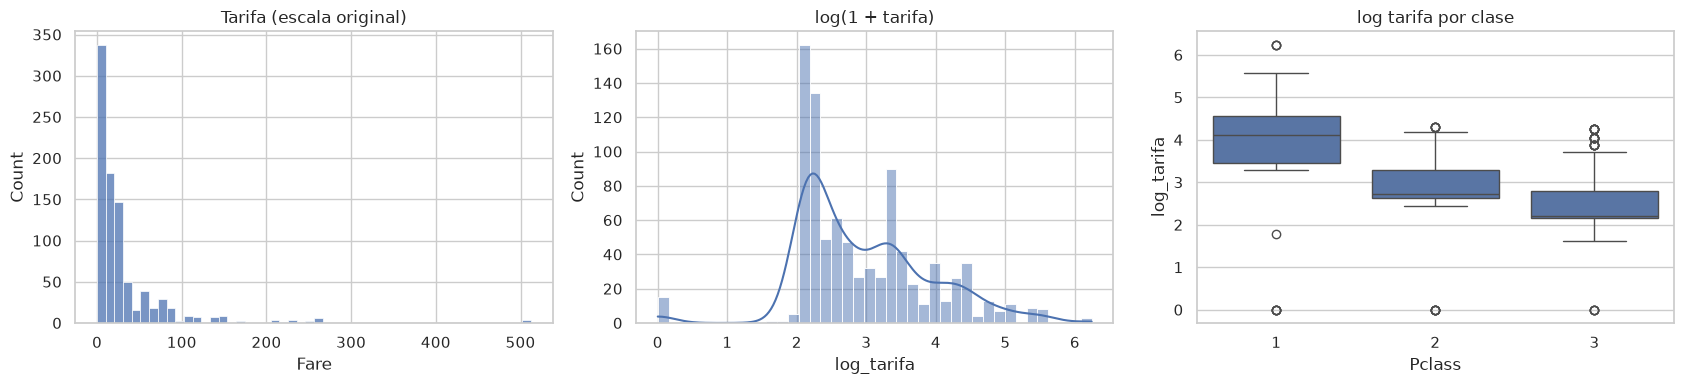

In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(df["Fare"], bins=50, ax=ejes[0]).set_title("Tarifa (escala original)")
sns.histplot(df["log_tarifa"], bins=40, kde=True, ax=ejes[1]).set_title("log(1 + tarifa)")
sns.boxplot(data=df, x="Pclass", y="log_tarifa", ax=ejes[2]).set_title("log tarifa por clase")
plt.tight_layout()
plt.show()

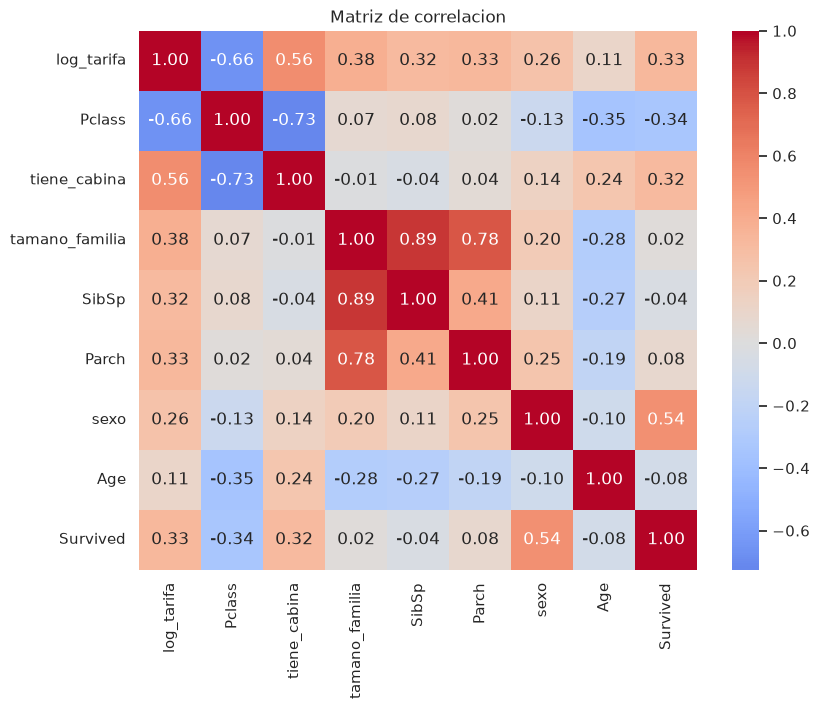

In [7]:
cols_corr = ["log_tarifa", "Pclass", "tiene_cabina", "tamano_familia", "SibSp", "Parch", "sexo", "Age", "Survived"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlacion")
plt.show()

Lo que sacamos del análisis exploratorio:

1. La tarifa es muy asimétrica: la mayoría pagó menos de 31 dólares, pero hay tarifas de hasta 512. Su IQR ratio es 0.045, por debajo de 0.05, y tiene 116 outliers. Con el logaritmo el IQR ratio sube a 0.205 y los outliers bajan a 31, así que usamos `log_tarifa` como objetivo. Los outliers son tarifas reales de primera clase, por eso no se eliminan. Hay 15 tarifas en cero que parecen ser tripulación o invitados, y también las dejamos.
2. `Parch` tiene IQR igual a cero porque la mayoría viajaba sin padres ni hijos.
3. La clase es la variable más relacionada con la tarifa (correlación de 0.66 con el logaritmo, negativa porque la clase 1 es la más cara). Después vienen `tiene_cabina` (0.56) y `tamano_familia` (0.38).
4. La mediana de la tarifa es de 60 dólares en primera clase, 14 en segunda y 8 en tercera.

### División y métricas

Separamos 80 % para entrenar y 20 % para probar, con semilla fija.

**R²:** proporción de la variación del objetivo que explica el modelo (1 es perfecto, 0 es igual a predecir el promedio). **MSE:** promedio de los errores al cuadrado, $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$. **R:** correlación entre el valor real y el predicho.

Como el objetivo es `log_tarifa`, el MSE queda en escala logarítmica. Para interpretarlo mejor también mostramos el error absoluto medio en dólares después de deshacer el logaritmo.

In [8]:
train, test = train_test_split(df, test_size=0.2, random_state=SEMILLA)
print("Entrenamiento:", len(train), "| Prueba:", len(test))


def evaluar_regresion(columnas, nombre):
    # Entrena la regresion y calcula las metricas en prueba
    modelo = LinearRegression().fit(train[columnas], train["log_tarifa"])
    pred = modelo.predict(test[columnas])
    return modelo, pred, {
        "modelo": nombre,
        "n_variables": len(columnas),
        "R": np.corrcoef(test["log_tarifa"], pred)[0, 1],
        "R2_train": r2_score(train["log_tarifa"], modelo.predict(train[columnas])),
        "R2_test": r2_score(test["log_tarifa"], pred),
        "MSE_test": mean_squared_error(test["log_tarifa"], pred),
        "error_medio_dolares": np.mean(np.abs(np.expm1(pred) - test["Fare"])),
    }


mse_base = mean_squared_error(test["log_tarifa"], np.full(len(test), train["log_tarifa"].mean()))
print(f"MSE de predecir siempre el promedio: {mse_base:.3f}")

Entrenamiento: 712 | Prueba: 179
MSE de predecir siempre el promedio: 0.847


## 4. Caso 1: regresión lineal simple

**Enunciado.** Seleccionar una única columna característica y una variable objetivo, obtener R y MSE y sacar conclusiones.

**Objetivo:** `log_tarifa`. **Característica:** `Pclass`, la variable con mayor correlación con la tarifa. Es ordinal (1, 2, 3), así que tiene sentido tratarla como número.

In [9]:
modelo_1, pred_1, met_1 = evaluar_regresion(["Pclass"], "Caso 1: Pclass")
print(f"Intercepto: {modelo_1.intercept_:.3f} | Coeficiente de Pclass: {modelo_1.coef_[0]:.3f}")
pd.DataFrame([met_1]).round(4)

Intercepto: 4.766 | Coeficiente de Pclass: -0.777


,modelo,n_variables,R,R2_train,R2_test,MSE_test,error_medio_dolares
0,Caso 1: Pclass,1,0.6981,0.4265,0.4827,0.4376,15.6298


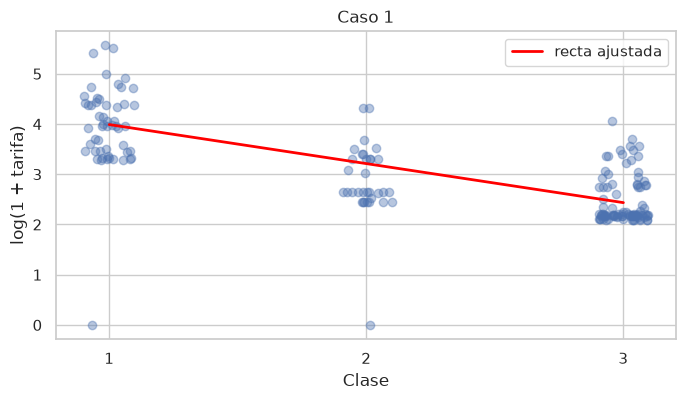

In [10]:
plt.figure(figsize=(8, 4))
plt.scatter(test["Pclass"] + np.random.default_rng(SEMILLA).uniform(-0.1, 0.1, len(test)), test["log_tarifa"], alpha=0.4)
xs = np.array([1, 3])
plt.plot(xs, modelo_1.intercept_ + modelo_1.coef_[0] * xs, color="red", lw=2, label="recta ajustada")
plt.xticks([1, 2, 3])
plt.xlabel("Clase")
plt.ylabel("log(1 + tarifa)")
plt.title("Caso 1")
plt.legend()
plt.show()

### Conclusiones del caso 1

Con solo la clase del pasajero el modelo explica cerca del 48 % de la variación de la tarifa (R² de 0.483 en prueba, R de 0.698). El MSE baja de 0.847 (predecir el promedio) a 0.438. El coeficiente es de 0.777 negativo: cada clase más barata reduce el logaritmo de la tarifa en 0.78, lo que equivale a pagar más o menos la mitad.

Como `Pclass` solo tiene tres valores, el modelo solo puede dar tres predicciones distintas, y toda la variación de precios dentro de una misma clase queda sin explicar. El error medio en dólares es de 15.6.

## 5. Caso 2: regresión lineal múltiple

**Enunciado.** Seleccionar dos columnas características, obtener R y MSE y agregar las columnas necesarias para mejorar las métricas.

Empezamos con `Pclass` y `tamano_familia`, porque en los grupos familiares el precio del tiquete muchas veces era la suma de todos los pasajes. Después agregamos `tiene_cabina`, luego sexo y edad, y al final el puerto y el título.

In [11]:
pasos = {
    "Paso A: Pclass + tamano_familia": ["Pclass", "tamano_familia"],
    "Paso B: + tiene_cabina": ["Pclass", "tamano_familia", "tiene_cabina"],
    "Paso C: + sexo y edad": ["Pclass", "tamano_familia", "tiene_cabina", "sexo", "Age", "edad_faltante"],
    "Paso D: + puerto y titulo": ["Pclass", "tamano_familia", "tiene_cabina", "sexo", "Age", "edad_faltante"]
                                  + cols_puerto[1:] + cols_titulo[1:],
}
resultados = [met_1]
for nombre, columnas in pasos.items():
    modelo, pred, met = evaluar_regresion(columnas, nombre)
    resultados.append(met)
tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla

,n_variables,R,R2_train,R2_test,MSE_test,error_medio_dolares
modelo,,,,,,
Caso 1: Pclass,1,0.6981,0.4265,0.4827,0.4376,15.6298
Paso A: Pclass + tamano_familia,2,0.8073,0.6132,0.6507,0.2955,11.8239
Paso B: + tiene_cabina,3,0.8176,0.6190,0.6678,0.2810,11.4687
Paso C: + sexo y edad,6,0.8189,0.6276,0.6694,0.2797,11.2420
Paso D: + puerto y titulo,12,0.8262,0.6419,0.6780,0.2724,10.7729


Coeficientes paso A: {'Pclass': np.float64(-0.811), 'tamano_familia': np.float64(0.253)}


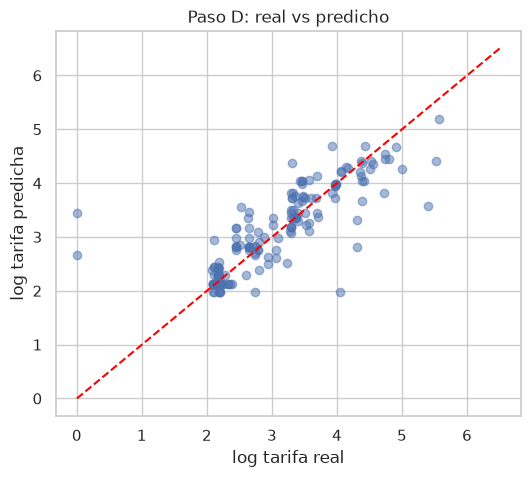

In [12]:
# Coeficientes del paso A y grafica real vs predicho del modelo final
modelo_a, _, _ = evaluar_regresion(pasos["Paso A: Pclass + tamano_familia"], "A")
print("Coeficientes paso A:", dict(zip(pasos["Paso A: Pclass + tamano_familia"], modelo_a.coef_.round(3))))

modelo_d, pred_d, _ = evaluar_regresion(pasos["Paso D: + puerto y titulo"], "D")
plt.figure(figsize=(6, 5))
plt.scatter(test["log_tarifa"], pred_d, alpha=0.5)
plt.plot([0, 6.5], [0, 6.5], color="red", ls="--")
plt.xlabel("log tarifa real")
plt.ylabel("log tarifa predicha")
plt.title("Paso D: real vs predicho")
plt.show()

### Conclusiones del caso 2

Agregar `tamano_familia` a la clase da el salto más grande de todo el ejercicio: el R² sube de 0.48 a 0.65 y el MSE baja de 0.438 a 0.296. El coeficiente del tamaño de familia es positivo (0.253). Esto confirma que en el Titanic el tiquete se compraba por grupo y la tarifa registrada es el total que pagó la familia, no el precio por persona.

Las demás variables aportan poco: `tiene_cabina` sube el R² a 0.668, sexo y edad casi no cambian nada (0.669) y el puerto y el título lo llevan a 0.678. El error medio queda en 10.8 dólares. El R² de entrenamiento y el de prueba son parecidos en todos los pasos, así que no hay sobreajuste.

## 6. Conclusiones generales

1. Para predecir la tarifa bastan prácticamente dos variables: la clase y el tamaño del grupo familiar. Con eso se explica el 65 % de la variación, y con todas las variables apenas se llega al 68 %.
2. Aplicar el logaritmo a la tarifa fue necesario. Sin él, los pocos tiquetes de más de 200 dólares dominarían el ajuste de la recta.
3. Una variable ordinal como la clase funciona en regresión lineal porque la tarifa sí baja de forma ordenada de primera a tercera clase.